Email Spam Detection with Machine Learning

1. Know Your Data

Import Libraries

In [1]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation mertic libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, classification_report

from wordcloud import WordCloud, STOPWORDS

# Library used for data processing
from sklearn.feature_extraction.text import CountVectorizer

# Import model selection library
from sklearn.model_selection import train_test_split

# Library used for ML Model implementation
from sklearn.naive_bayes import MultinomialNB

# Importing the pipeline class for scikit-learn
from sklearn.pipeline import Pipeline

# Library used for ignore warnings
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline

Dataset Loading

In [2]:
# Load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

Dataset First View

In [3]:
# Dataset first look
# View top 5 rows of the dataset
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Dataset Rows and Columns Count

In [4]:
# Dataset Rows and Columns Count
# Checking number of rows and columns of the dataset using shape attribute of the dataframe.
print("Number of rows are: ", df.shape[0])
print("Number of columns are: ", df.shape[1])

Number of rows are:  5572
Number of columns are:  5


Dataset Information

In [5]:
# Dataset Info
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Duplicate Values

In [6]:
# Dataset duplicate Value count
# gives the total number of duplicate values in the dataset
dup = df.duplicated().sum()
print(f'number of duplicated rows are: {dup}')

number of duplicated rows are: 403


Missing Values/Null Values

In [7]:
# Missing Values/ Null Values Count
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

What did i know about the dataset?
1. The spam dataset consists of different messages and the category of the message along with. 
2. There are rows 5572 rows and 5 columns provided in the data.
3. 403 duplicate rows are present in the dataset.
4. No Null values exist in v1 & v2 column, but lots of null values present in unnamed 2,3,4 columns (will drop those 3 columns later)


2. Understanding the Variables in the dataset

In [8]:
# Dataset columns
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
# Dataset Describe (all coulmns included)
# gives the statistical summary of the dataset for all columns including categorical and numerical columns.
df.describe(include= 'all').round(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


Check Unique values for each variable.

In [10]:
# Check Unique Values fr each variable using a for loop.
for i in df.columns.tolist():
    print("No. of unique values in", i, "is: ", df[i].nunique())

No. of unique values in v1 is:  2
No. of unique values in v2 is:  5169
No. of unique values in Unnamed: 2 is:  43
No. of unique values in Unnamed: 3 is:  10
No. of unique values in Unnamed: 4 is:  5


3. Data Wrangling

In [11]:
# Change the v1 & v2coulmns as category and message
df.rename(columns={"v1": "Category", "v2": "Message"}, inplace=True)

In [12]:
# Removing all unnamed columns
df.drop(columns={'Unnamed: 2','Unnamed: 3','Unnamed: 4'}, inplace=True)

In [13]:
# Create a binary 'Spam' column: 1 for 'Spam' and 0 for 'ham', based on the 'Category' column
df['Spam'] = df['Category'].apply(lambda x: 1 if x == 'spam' else 0)

In [14]:
# Updated new dataset
df.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


4. Data Visualization, Storytelling & Experimenting with charts: Understand the relationships between variables


Chart-1: Distribution of Spam and Ham

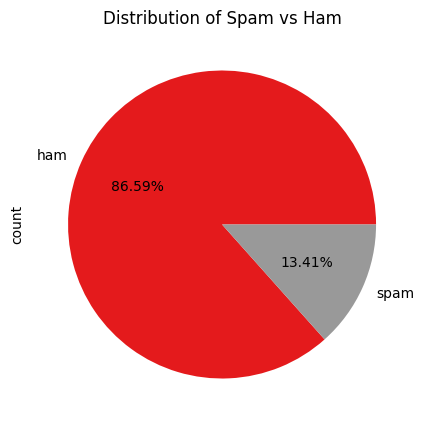

In [15]:
# Chart - 1 Pie Chart Visualization Code For Distribution of Spam vs Ham Messages
spread = df['Category'].value_counts()
plt.rcParams['figure.figsize'] = (5,5)

# Set Labels
spread.plot(kind = 'pie', autopct='%1.2f%%', cmap='Set1')
plt.title(f'Distribution of Spam vs Ham')

# Display the Chart
plt.show()

Insights found from the chart:-

From the above chart, we got to know that the dataset contain 13.41% of spam messages and 86.59% of ham messages

Chart - 2: Most Used Words in Spam Messages

In [16]:
# Spplitting Spam Messages
df_spam = df[df['Category']  == 'spam'].copy()

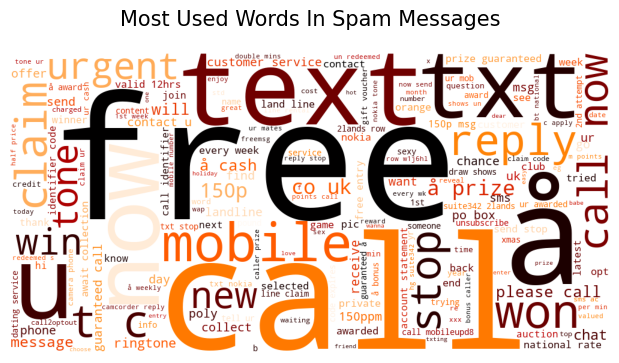

In [17]:
# Chart - 2 WordCloud Plot Visualization Code For Most Used Words in Spam Messages
# Create a String to Store All The Words
comment_words = ''

# Remove The Stopwords
stopwords = set(STOPWORDS)

# Iterate Through The Column
for val in df_spam.Message:

    # Typecaste Each Val to String
    val = str(val)

    # Split The Value
    tokens = val.split()

    # Converts Each Token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

# Set Parameters
wordcloud = WordCloud(width = 1000, height = 500,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10,
                max_words = 1000,
                colormap = 'gist_heat_r').generate(comment_words)

# Set Labels
plt.figure(figsize = (6,6), facecolor = None)
plt.title('Most Used Words In Spam Messages', fontsize = 15, pad=20)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

# Display Chart
plt.show()
     

insights found form the wordcloud chart:-

From the baove wordcloud plot, we got to know that the 'free', 'call', 'text', 'txt', and 'now' are the most used words in spam messages.

5. Feature Engineering & Data Pre-Processing

Data Splitting

In [18]:
# Splitting the data to train and test
X_train, X_test, y_train, y_test = train_test_split(df.Message, df.Spam, test_size = 0.25)

6. ML Model Implementation

In [19]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # fit the model on the training data
    model.fit(X_train, y_train)

    # make predictions on the test data
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    pred_prob_train = model.predict_proba(X_train)[:,1]
    pred_prob_test = model.predict_proba(X_test)[:,1]

    # calculate ROC AUC score
    roc_auc_train = roc_auc_score(y_train, y_pred_train)
    roc_auc_test = roc_auc_score(y_test, y_pred_test)
    print("\nTrain ROC AUC:", roc_auc_train)
    print("Test ROC AUC:", roc_auc_test)

    # plot the ROC curve
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, pred_prob_train)
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, pred_prob_test)
    plt.plot([0,1],[0,1],'k--')
    plt.plot(fpr_train, tpr_train, label="Train ROC AUC: {:.2f}".format(roc_auc_train))
    plt.plot(fpr_test, tpr_test, label="Test ROC AUC: {:.2f}".format(roc_auc_test))
    plt.legend()
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # calculate confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # calculate classification report
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print("\nTrain Classification Report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_train).T.iloc[:, :-1], annot=True, cmap="Blues")
    print("\nTest Classification Report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_test).T.iloc[:, :-1], annot=True, cmap="Blues")


    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, roc_auc_train, roc_auc_test, F1_train, F1_test ]
    return model_score


ML Model: Multinomial Naive Bayes

In [20]:
# ML Model - 1 Implementation
# Create a machine learning pipeline using scikit-learn, combining text vectorization (CountVectorizer)
# and a Multinomial Naive Bayes classifier for email spam detection.
clf = Pipeline([
    ('vectorizer', CountVectorizer()),  # Step 1: Text data transformation
    ('nb', MultinomialNB())  # Step 2: Classification using Naive Bayes
])


# Model is trained (fit) and predicted in the evaluate model

Explain the ML Model used and it's perforamnce using Evaluation metric Score Chart


Train ROC AUC: 0.9849368374922354
Test ROC AUC: 0.966499162479062


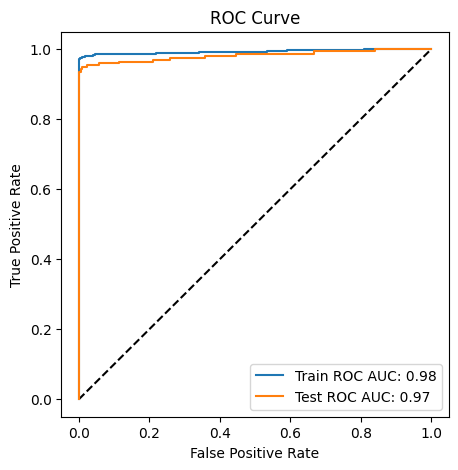


Confusion Matrix:


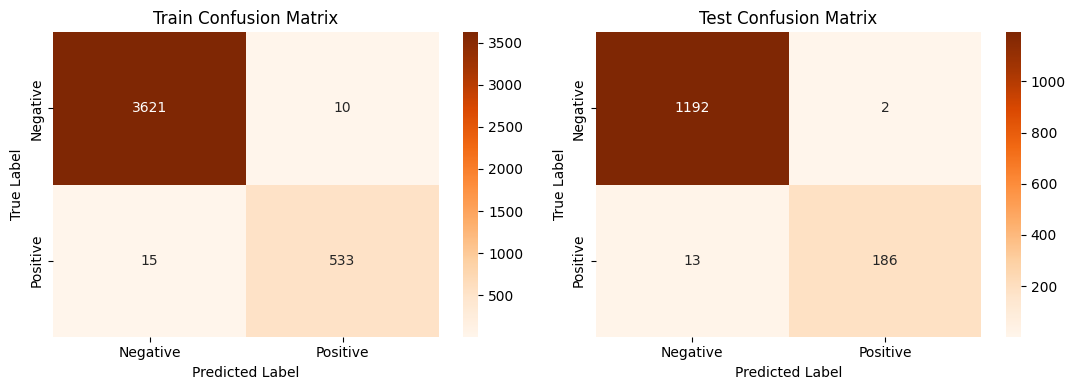


Train Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.995875 | 0.997246 |   0.99656  | 3631        |
| 1            |    0.981584 | 0.972628 |   0.977085 |  548        |
| accuracy     |    0.994018 | 0.994018 |   0.994018 |    0.994018 |
| macro avg    |    0.988729 | 0.984937 |   0.986823 | 4179        |
| weighted avg |    0.994001 | 0.994018 |   0.994006 | 4179        |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.989212 | 0.998325 |   0.993747 | 1194        |
| 1            |    0.989362 | 0.934673 |   0.96124  |  199        |
| accuracy     |    0.989232 | 0.989232 |   0.989232 |    0.989232 |
| macro avg    |    0.989287 | 0.966499 |   0.977494 | 1393        |
| weighted avg |    0.989233 | 0.989232 |   

In [21]:
# Visualizing evaluation Metric Score chart
MultinomialNB_score = evaluate_model(clf, X_train, X_test, y_train, y_test)

Email Spam Detection System

In [22]:
# Defining a function or thre Email Spam Detection system
def detect_spam(email_text):
    #Load the trained classifier (clf) here
    # REplace the comment with your code to Load the classifier model

    # Make a prediciton using the Loader classifer
    prediction = clf.predict([email_text])

    if prediction == 0:
        return "This nis a Ham Email!"
    
    else:
        return "this is a Spam Email!"


In [23]:
# Example of how to use the function
sample_email = 'Win Free Tickets for Coachella Music Festival! Click here to claim your prize.'
result = detect_spam(sample_email)
print(result)

this is a Spam Email!
